## Imports

In [109]:
import numpy as np
import os
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor

In [28]:
path = kagglehub.dataset_download("elikplim/forest-fires-data-set")

100%|██████████████████████████████████████| 7.10k/7.10k [00:00<00:00, 3.86MB/s]

Extracting files...


In [29]:
os.listdir(path)

['forestfires.csv']

In [30]:
df = pd.read_csv(os.path.join(path,'forestfires.csv'))

In [31]:
df.describe()

,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
count,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000
mean,4.669246,4.299807,90.644681,110.872340,547.940039,9.021663,18.889168,44.288201,4.017602,0.021663,12.847292
std,2.313778,1.229900,5.520111,64.046482,248.066192,4.559477,5.806625,16.317469,1.791653,0.295959,63.655818
min,1.000000,2.000000,18.700000,1.100000,7.900000,0.000000,2.200000,15.000000,0.400000,0.000000,0.000000
25%,3.000000,4.000000,90.200000,68.600000,437.700000,6.500000,15.500000,33.000000,2.700000,0.000000,0.000000
50%,4.000000,4.000000,91.600000,108.300000,664.200000,8.400000,19.300000,42.000000,4.000000,0.000000,0.520000
75%,7.000000,5.000000,92.900000,142.400000,713.900000,10.800000,22.800000,53.000000,4.900000,0.000000,6.570000
max,9.000000,9.000000,96.200000,291.300000,860.600000,56.100000,33.300000,100.000000,9.400000,6.400000,1090.840000


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    object 
 3   day     517 non-null    object 
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
 12  area    517 non-null    float64
dtypes: float64(8), int64(3), object(2)
memory usage: 52.6+ KB


In [33]:
df.isnull().values.any()

False

In [34]:
df.head(15)

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0
5,8,6,aug,sun,92.3,85.3,488.0,14.7,22.2,29,5.4,0.0,0.0
6,8,6,aug,mon,92.3,88.9,495.6,8.5,24.1,27,3.1,0.0,0.0
7,8,6,aug,mon,91.5,145.4,608.2,10.7,8.0,86,2.2,0.0,0.0
8,8,6,sep,tue,91.0,129.5,692.6,7.0,13.1,63,5.4,0.0,0.0
9,7,5,sep,sat,92.5,88.0,698.6,7.1,22.8,40,4.0,0.0,0.0


In [42]:
numeric_df = df.select_dtypes('int64', 'float64')

In [54]:
#Converts variables into dummy variables
df_encoded = pd.get_dummies(df, columns=['month', 'day'], dummy_na=True)

In [60]:
#Standard Scaler
X = data.drop('area', axis=1)
y = data['area']

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

In [66]:
#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [73]:
#Scaling both train and test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [96]:
#Linear regression
reg = LinearRegression()
reg.fit(X_train_scaled, y_train)
y_pred_reg = reg.predict(X_test_scaled)
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred_reg):.2f}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred_reg):.2f}")
print(f"R2 Score: {r2_score(y_test, y_pred_reg):.2f}")

Mean Squared Error: 11566.58
Mean Absolute Error: 25.57
R2 Score: 0.02


In [114]:
#Ridge Regression
rid = Ridge(alpha=1.0)
rid.fit(X_train_scaled, y_train)
y_pred_rid = rid.predict(X_test_scaled)
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred_rid):.2f}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred_rid):.2f}")
print(f"R2 Score: {r2_score(y_test, y_pred_rid):.2f}")

Mean Squared Error: 11583.46
Mean Absolute Error: 25.24
R2 Score: 0.02


In [121]:
#Lasso Regression
las = Lasso(0.025)
las.fit(X_train_scaled, y_train)
y_pred_las = las.predict(X_test_scaled)
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred_las):.2f}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred_las):.2f}")
print(f"R2 Score: {r2_score(y_test, y_pred_las):.2f}")

Mean Squared Error: 11582.92
Mean Absolute Error: 25.26
R2 Score: 0.02


In [122]:
#SVR
svr = SVR(C=1, epsilon=0.1)
svr.fit(X_train_scaled, y_train)
y_pred_svr = svr.predict(X_test_scaled)
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred_svr):.2f}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred_svr):.2f}")
print(f"R2 Score: {r2_score(y_test, y_pred_svr):.2f}")

Mean Squared Error: 12123.72
Mean Absolute Error: 19.64
R2 Score: -0.03


In [132]:
#Random Forest Regression
rfr = RandomForestRegressor(n_estimators=100, max_depth=None, min_samples_split=2, min_samples_leaf=1, random_state=42)
rfr.fit(X_train_scaled, y_train)
y_pred_rfr = rfr.predict(X_test_scaled)
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred_rfr):.2f}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred_rfr):.2f}")
print(f"R2 Score: {r2_score(y_test, y_pred_rfr):.2f}")

Mean Squared Error: 12779.34
Mean Absolute Error: 29.23
R2 Score: -0.08


In [129]:
feature_importances = pd.Series(rfr.feature_importances_, index=X_train.columns)
feature_importances = feature_importances.sort_values(ascending=False)

print(feature_importances)

DMC          1.793926e-01
temp         1.685982e-01
RH           9.795018e-02
wind         8.815626e-02
Y            8.122076e-02
FFMC         7.076340e-02
X            5.853067e-02
ISI          5.460864e-02
DC           5.011029e-02
day_thu      3.151935e-02
day_sat      3.029404e-02
day_mon      2.369787e-02
month_jul    1.755487e-02
day_sun      1.089052e-02
month_aug    1.043100e-02
day_wed      7.346229e-03
month_sep    5.450410e-03
day_tue      4.578495e-03
month_may    2.304625e-03
month_jun    1.823376e-03
rain         1.768841e-03
month_oct    1.019671e-03
month_feb    8.967427e-04
month_mar    6.189771e-04
month_dec    4.740024e-04
month_nov    1.230743e-21
month_jan    0.000000e+00
dtype: float64


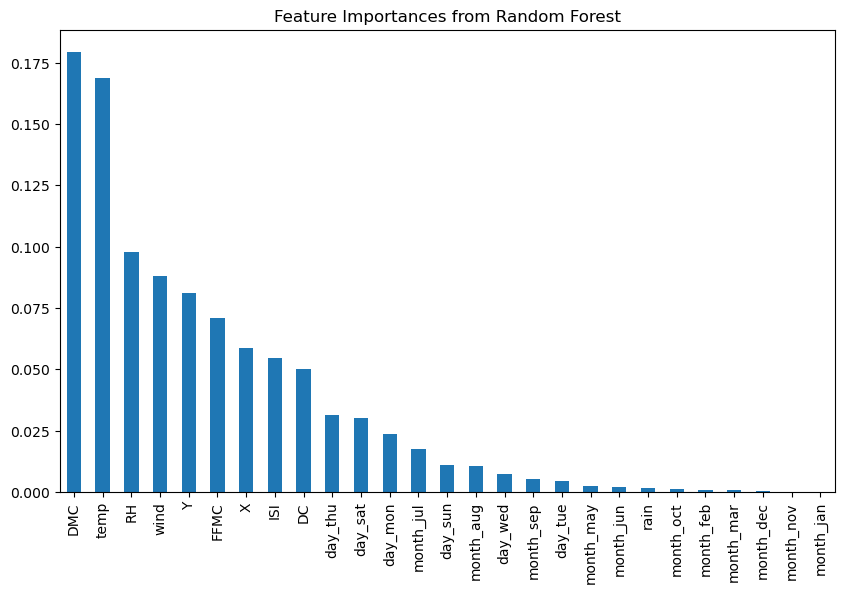

In [131]:
plt.figure(figsize=(10,6))
feature_importances.plot(kind='bar')
plt.title("Feature Importances from Random Forest")
plt.show()